
# 3. Exploración inicial de datos 

En esta sección se desarrolla una exploración inicial del conjunto de datos de nivel empleado en el estudio. En primer lugar, se examinan las dimensiones del dataset, los tipos de datos y los valores faltantes de las series con el fin de verificar su consistencia y alcance. Posteriormente, se analizan las características estadísticas y distributivas de las variables mediante histogramas y diagramas de caja, lo que permite reconocer tendencias generales, dispersión, asimetrías y posibles valores atípicos antes de avanzar hacia análisis de correlación.




## 3.1. Inspección inicial de datos

In [87]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ruta = r"C:\Users\Victus\Documents\Academico\MCT\Semestre2\MachineLearning\PF\DatosNivel\Niveles_alineados.csv"
df = pd.read_csv(ruta, parse_dates=["Fecha"])

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
df = df.sort_values("Fecha").reset_index(drop=True)

df.head()


,Fecha,Calamar,Achi,ElBanco,SaladoBlanco,PuertoBerrio,Barrancabermeja
0,1975-06-29,564.0,545.0,660.0,216.0,359.0,230.0
1,1975-06-30,562.0,550.0,NaN,250.0,384.0,280.0
2,1975-07-01,559.0,558.0,NaN,230.0,408.0,280.0
3,1975-07-02,564.0,587.0,NaN,171.0,404.0,315.0
4,1975-07-03,568.0,603.0,NaN,172.0,411.0,285.0


In [88]:
# Dimensión, tipo de datos, rango temporal

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

Dimensiones del dataset: (18398, 7)

Tipos de datos:
Fecha              datetime64[ns]
Calamar                   float64
Achi                      float64
ElBanco                   float64
SaladoBlanco              float64
PuertoBerrio              float64
Barrancabermeja           float64
dtype: object


In [89]:
# Rango temporal

print("\nFecha inicial:", df["Fecha"].min()) 
print("Fecha final:", df["Fecha"].max()) 
print("Número de fechas únicas:", df["Fecha"].nunique())


Fecha inicial: 1975-06-29 00:00:00
Fecha final: 2025-11-10 00:00:00
Número de fechas únicas: 18398


In [90]:
# Resumen DataFrame

df.info()
df[["Calamar", "Achi", "ElBanco","SaladoBlanco","PuertoBerrio","Barrancabermeja"]].describe().round(2)

num_cols = df.select_dtypes(include=['number']).columns.tolist()
stats = df[num_cols].describe().T.round(2)
stats['skewness'] = df[num_cols].skew().round(2)
stats['kurtosis'] = df[num_cols].kurtosis().round(2)
stats['missing%'] = (df[num_cols].isnull().mean() * 100).round(2)
stats['coef variat'] = (df[num_cols].std() / df[num_cols].mean()).round(3)

print(stats.round(2).to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18398 entries, 0 to 18397
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fecha            18398 non-null  datetime64[ns]
 1   Calamar          18248 non-null  float64       
 2   Achi             14831 non-null  float64       
 3   ElBanco          17978 non-null  float64       
 4   SaladoBlanco     18240 non-null  float64       
 5   PuertoBerrio     18015 non-null  float64       
 6   Barrancabermeja  17461 non-null  float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1006.3 KB
                   count    mean     std     min     25%    50%    75%    max  skewness  kurtosis  missing%  coef variat
Calamar          18248.0  548.04  168.75  112.00  436.61  553.0  670.0  950.0     -0.19     -0.55      0.82         0.31
Achi             14831.0  461.32  142.26   50.00  366.00  462.0  554.0  829.0      0.02     -0.30     19.39    

In [91]:
# Datos faltantes

df.isnull().sum()

Fecha                 0
Calamar             150
Achi               3567
ElBanco             420
SaladoBlanco        158
PuertoBerrio        383
Barrancabermeja     937
dtype: int64

## 3.2. Histogramas de las series

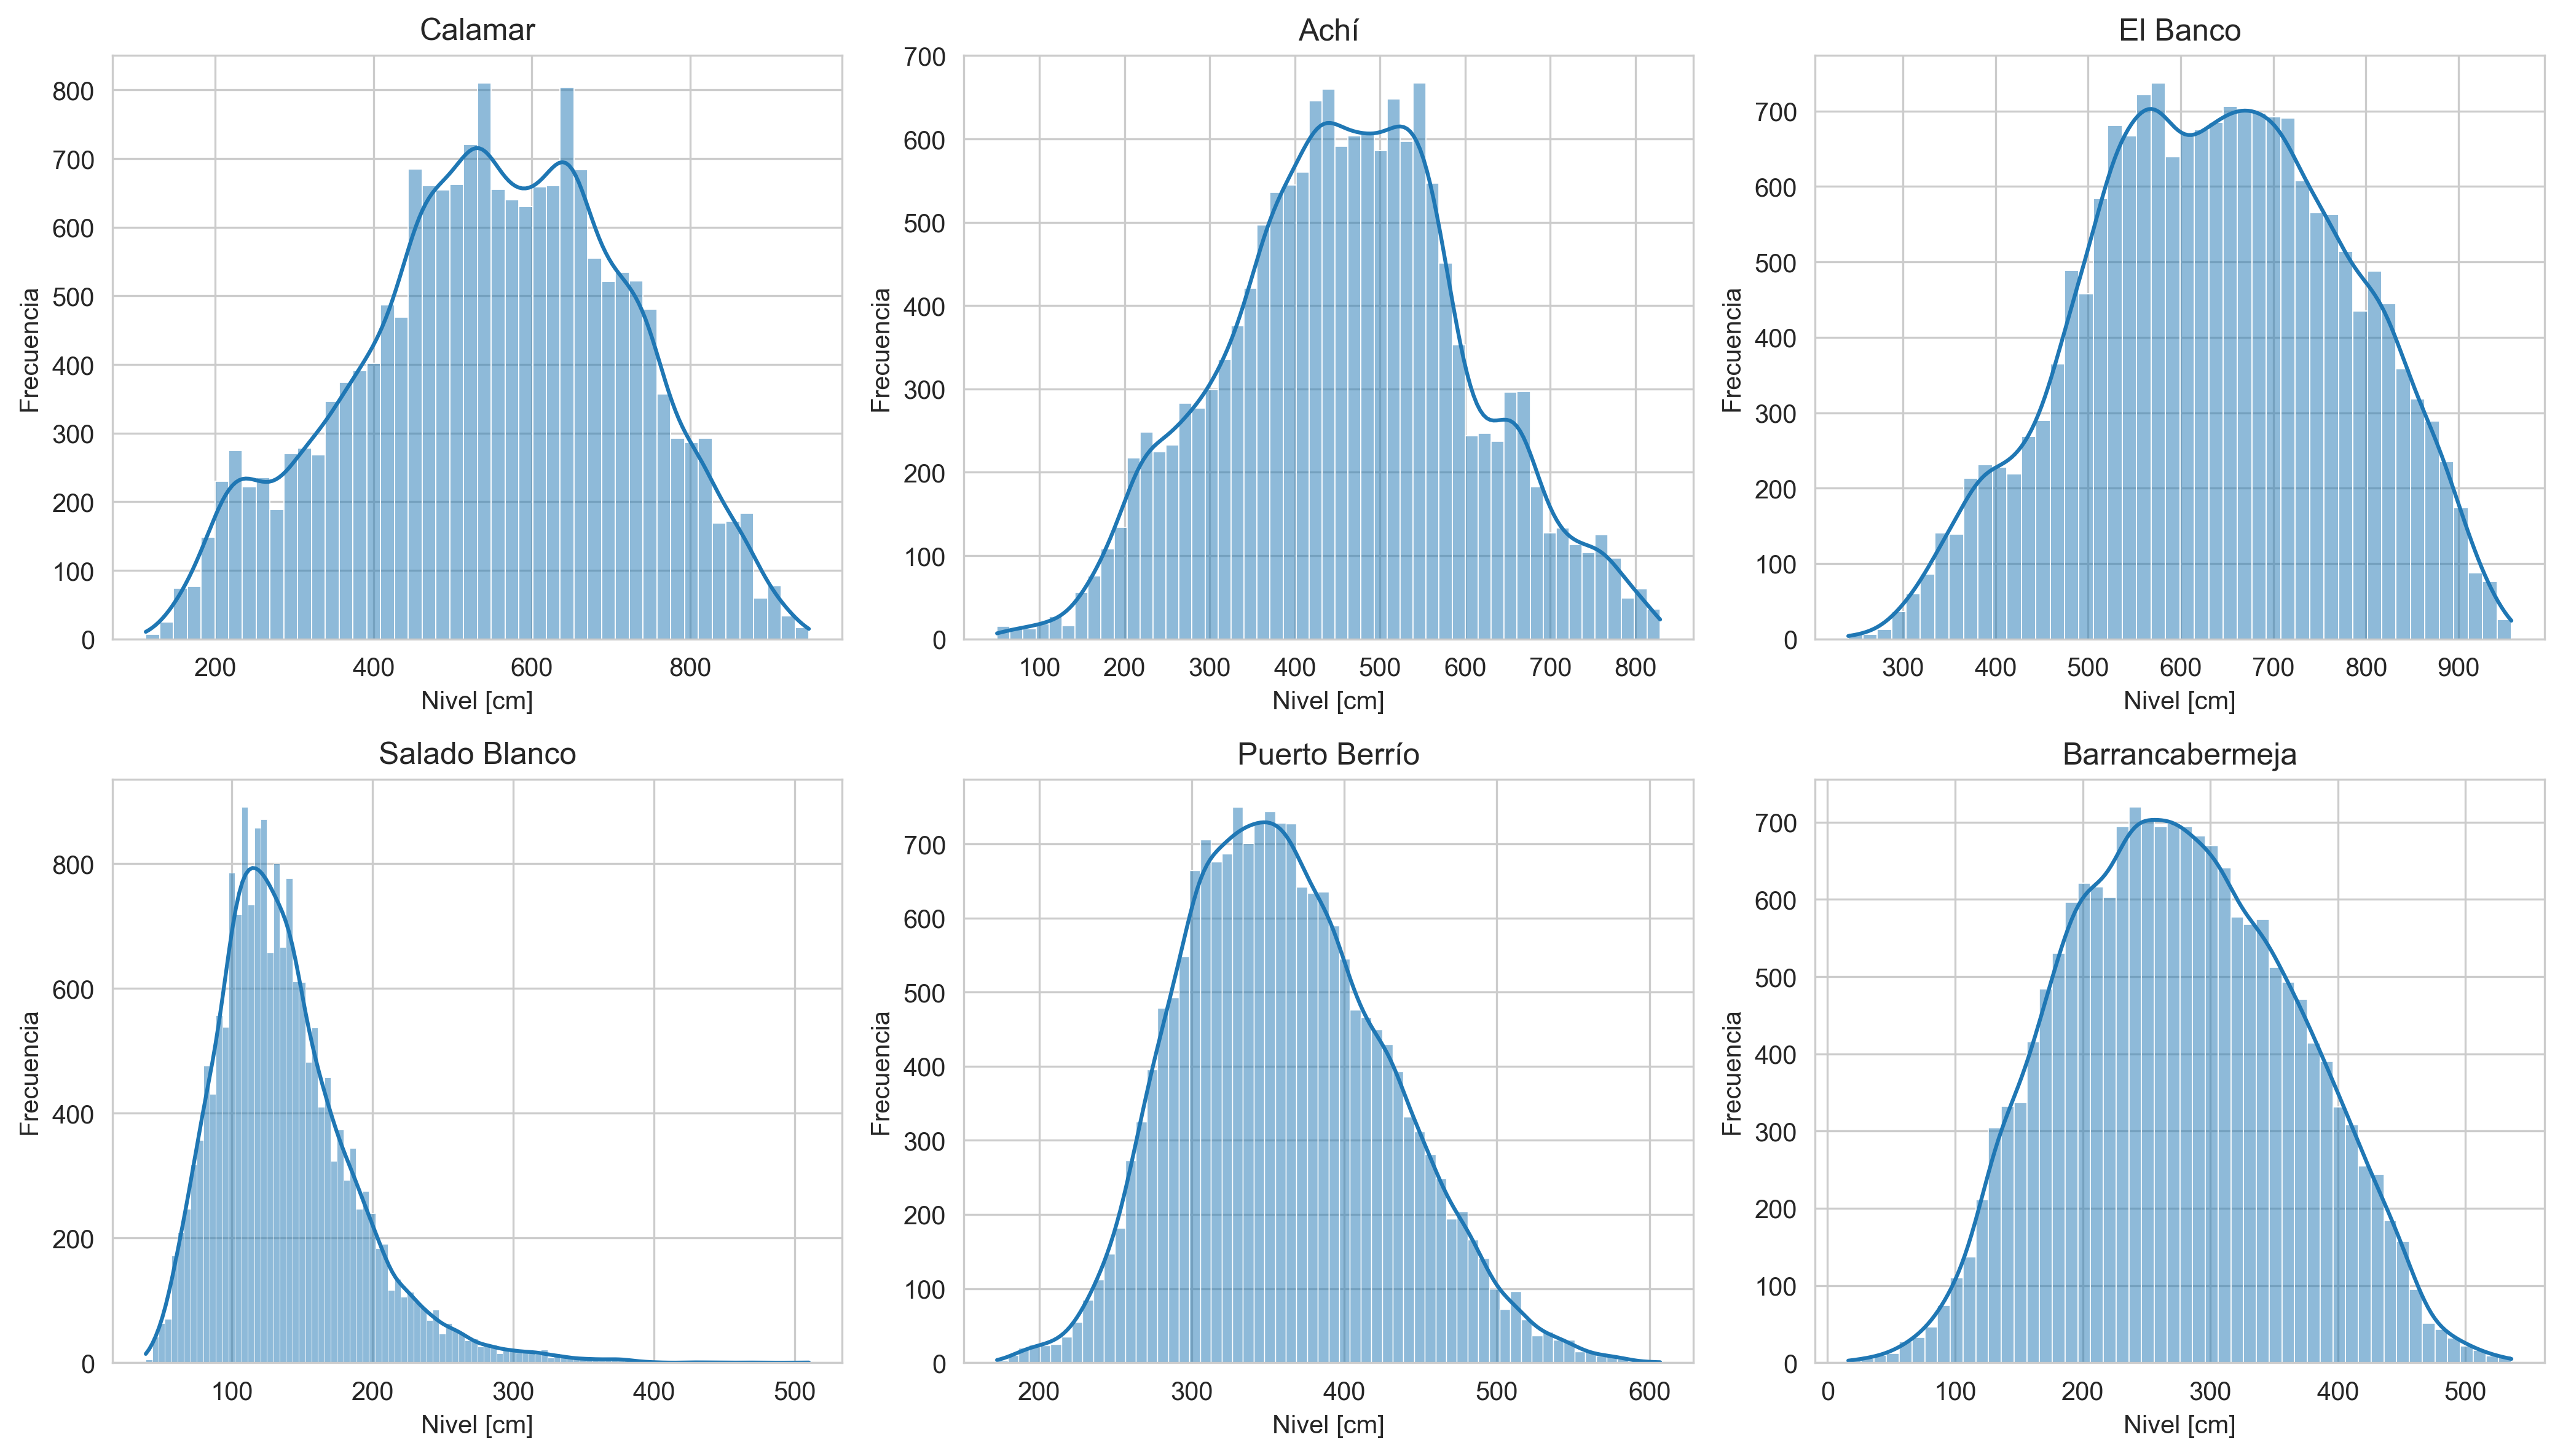

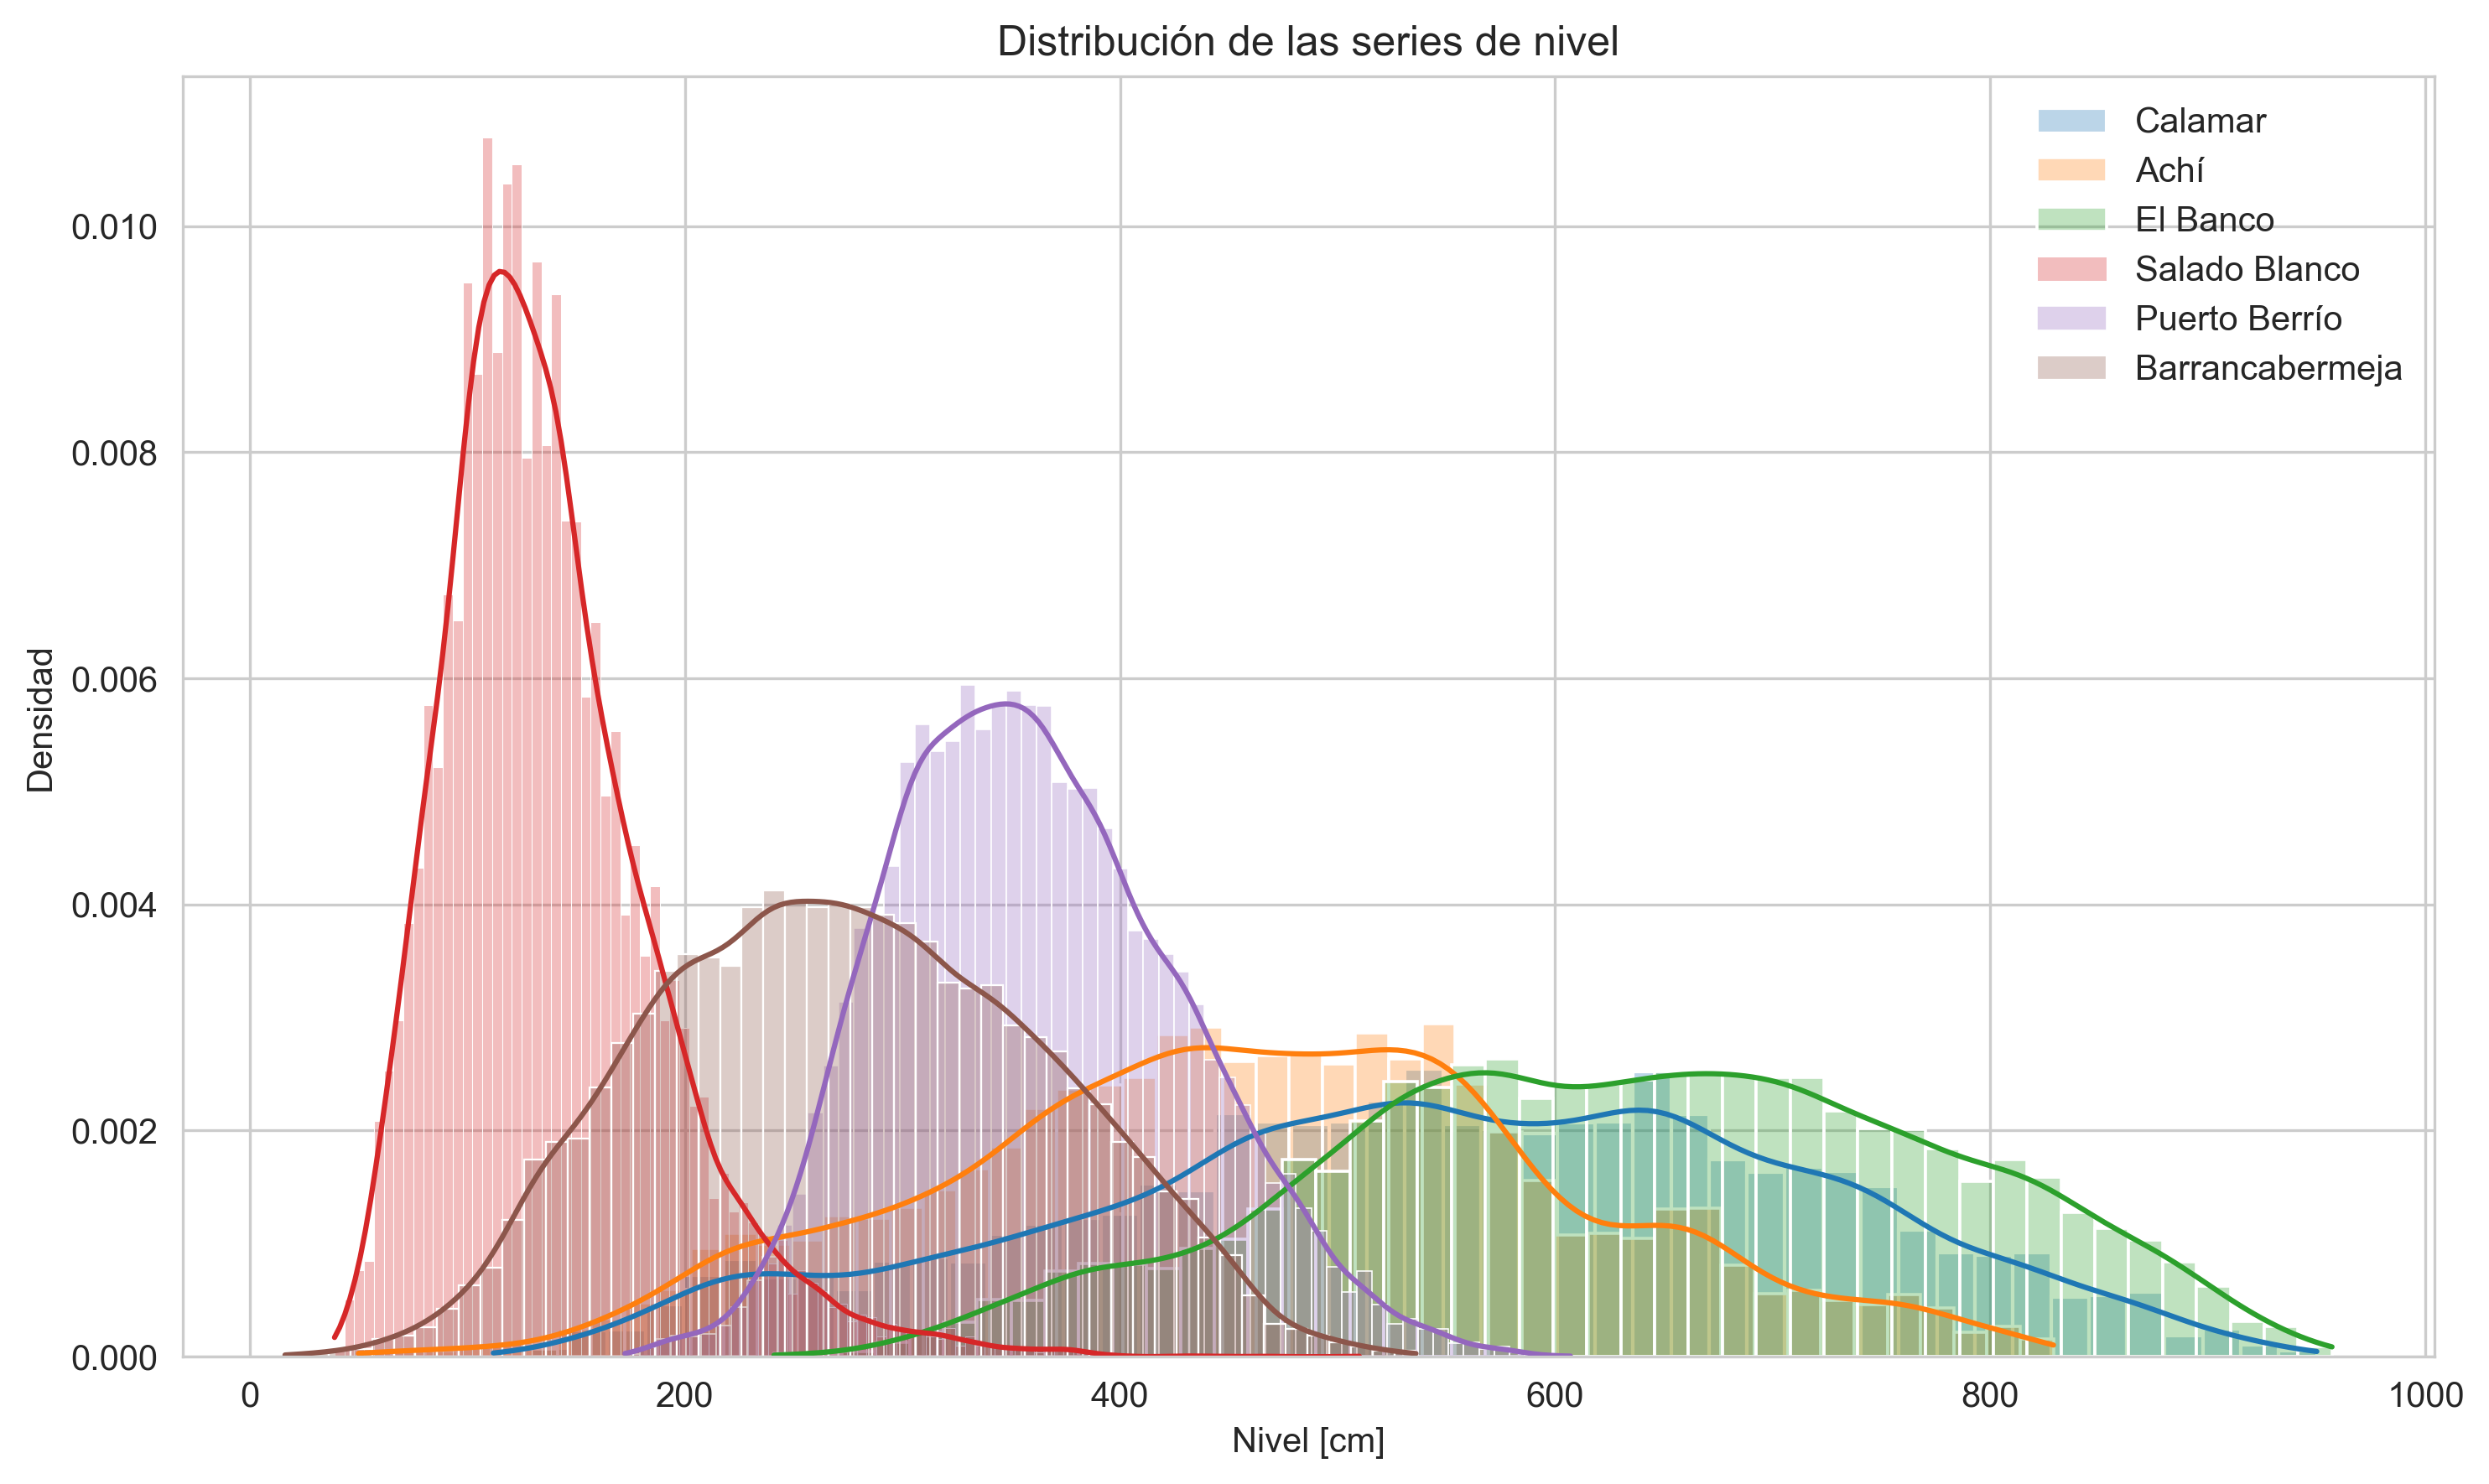

In [92]:

import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=300)
axes = axes.flatten()

sns.histplot(df["Calamar"].dropna(), kde=True, ax=axes[0])
axes[0].set_title("Calamar")

sns.histplot(df["Achi"].dropna(), kde=True, ax=axes[1])
axes[1].set_title("Achí")

sns.histplot(df["ElBanco"].dropna(), kde=True, ax=axes[2])
axes[2].set_title("El Banco")

sns.histplot(df["SaladoBlanco"].dropna(), kde=True, ax=axes[3])
axes[3].set_title("Salado Blanco")

sns.histplot(df["PuertoBerrio"].dropna(), kde=True, ax=axes[4])
axes[4].set_title("Puerto Berrío")

sns.histplot(df["Barrancabermeja"].dropna(), kde=True, ax=axes[5])
axes[5].set_title("Barrancabermeja")

for ax in axes:
    ax.set_xlabel("Nivel [cm]")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


# Plot unidos
plt.figure(figsize=(10, 6), dpi=300)

sns.histplot(df["Calamar"].dropna(), kde=True, stat="density", alpha=0.30, label="Calamar")
sns.histplot(df["Achi"].dropna(), kde=True, stat="density", alpha=0.30, label="Achí")
sns.histplot(df["ElBanco"].dropna(), kde=True, stat="density", alpha=0.30, label="El Banco")
sns.histplot(df["SaladoBlanco"].dropna(), kde=True, stat="density", alpha=0.30, label="Salado Blanco")
sns.histplot(df["PuertoBerrio"].dropna(), kde=True, stat="density", alpha=0.30, label="Puerto Berrío")
sns.histplot(df["Barrancabermeja"].dropna(), kde=True, stat="density", alpha=0.30, label="Barrancabermeja")

plt.title("Distribución de las series de nivel")
plt.xlabel("Nivel [cm]")
plt.ylabel("Densidad")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## 3.3. Box Plots de las series de nivel

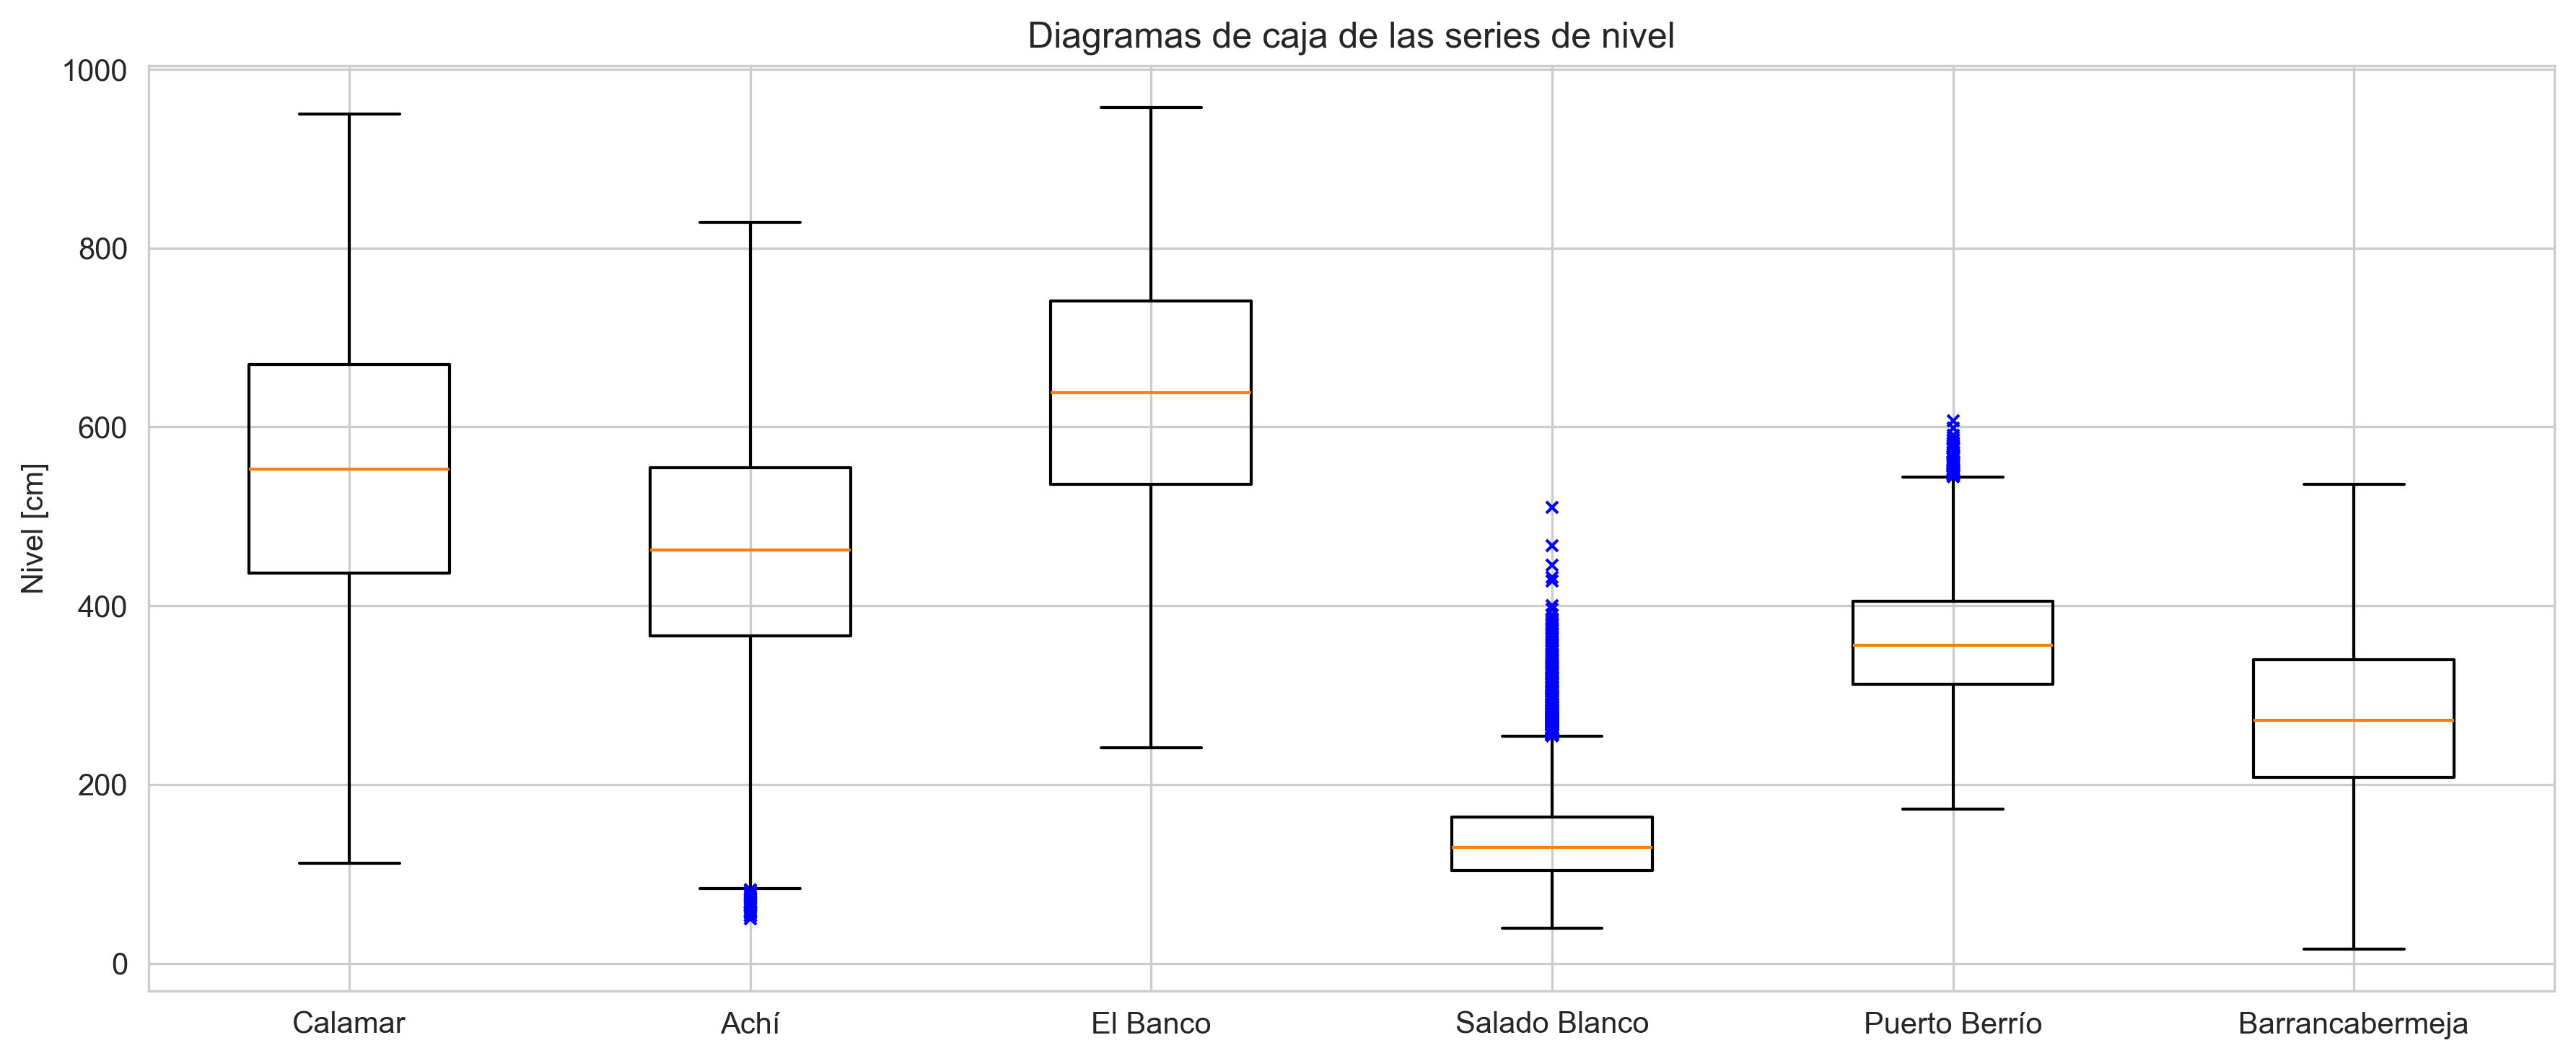

In [93]:
plt.figure(figsize=(12, 5), dpi=300)

plt.boxplot(
    [
        df["Calamar"].dropna(),
        df["Achi"].dropna(),
        df["ElBanco"].dropna(),
        df["SaladoBlanco"].dropna(),
        df["PuertoBerrio"].dropna(),
        df["Barrancabermeja"].dropna()
    ],
    tick_labels=[
        "Calamar",
        "Achí",
        "El Banco",
        "Salado Blanco",
        "Puerto Berrío",
        "Barrancabermeja"
    ],
    flierprops=dict(
        marker='x',
        markeredgecolor='blue',
        markersize=4,
        linestyle='none'
    )
)

plt.title("Diagramas de caja de las series de nivel")
plt.ylabel("Nivel [cm]")
plt.tight_layout()
plt.show()